In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 3** - Drug Discovery Project

- **Objective** - drug discovery project, testing combinations of three compounds to create a new medicine.
- Each experiment is stored in `initial_inputs.npy` as a 3D array, where each row lists the amounts of the three compounds used.
  - After each experiment, you record the number of adverse reactions, stored in `initial_outputs.npy` as a 1D array.

- **Final Goal** - minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects).

- **Input:** 3D array (15, 3)
- **Output:** 3D array (15,)
- **Optimization Goal** - maximisation


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_3\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_3\initial_outputs.npy')

In [3]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.021588, 0.984211, 0.542109], dtype=np.float64)
Y_w1_new_point = np.array([-0.05771366829132032], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w1_new_point))
Y_updated = np.append(Y, Y_w1_new_point)

# Save the updated arrays
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_2\initial_inputs.npy', X_updated)
np.save(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_2\initial_outputs.npy', Y_updated)

In [4]:
print("Updated Inputs (X) - Function 3: ", X_updated)
print("Updated Outputs (Y) - Function 3: ", Y_updated)

Updated Inputs (X) - Function 3:  [[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]
 [0.021588   0.984211   0.542109  ]]
Updated Outputs (Y) - Function 3:  [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.05771367]


### **Interpretation of the output and potential next steps to improve the model**


I will be moving away from the random search as I got an initial impression of the 3D space.

- Now my current strategy is going to be to continue using the expected improvement surrogate model to find the best next query points.
  - I have explored this in detail in Week 1 function 3 analysis section.

- The output that I got for Week 1 for Function 3 using random search was -0.058.
  - This means that the current query was not ideal as I since the function goal is to maximise the negative of side effects, being realively near 0 means that it is a safe start.


### **Bayesian Optimisation** - Matern kernel with Gaussian Proceeses Modeling

- For this particular problem I am using the Matern kerenl as in comparison the RBF kerel is a bit too smooth whereas in this paricular looking at the use case we need to use a Matern.
  - This should help us capture the sensitive chemical interactions while still remaining differentiable.


In [5]:
kernel = Matern(length_scale=1.0, nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=0.01,
    normalize_y=True,
    random_state=42
)

model.fit(X_updated, Y_updated)

GaussianProcessRegressor(alpha=0.01, kernel=Matern(length_scale=1, nu=2.5),
                         n_restarts_optimizer=10, normalize_y=True,
                         random_state=42)

### **Acquisition Function** - Expected Improvement (EI)

- I want to use expected improvements (EI) as it is superior for higher dimensions.
  - Particularly reason for me to choose this is that it looks for the "Expected" value of the improvement.
    - This helps navigate the larger 3D search space more efficiently.


In [7]:
def expected_improvement(X_updated, model, y_max, xi=0.01):
    mu, sigma = model.predict(X_updated, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    
    return ei.ravel()

y_max = np.max(Y_updated)

x_grid = np.random.uniform(0, 1, size=(50000, 3))

ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"\nNext query point for Function 3 suggested by EI acquisition function: [{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}]")


Next query point for Function 3 suggested by EI acquisition function: [0.342299-0.341527-0.471239]


### **Visualisation of the search map and progress plot**


C:\Users\Pratham\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


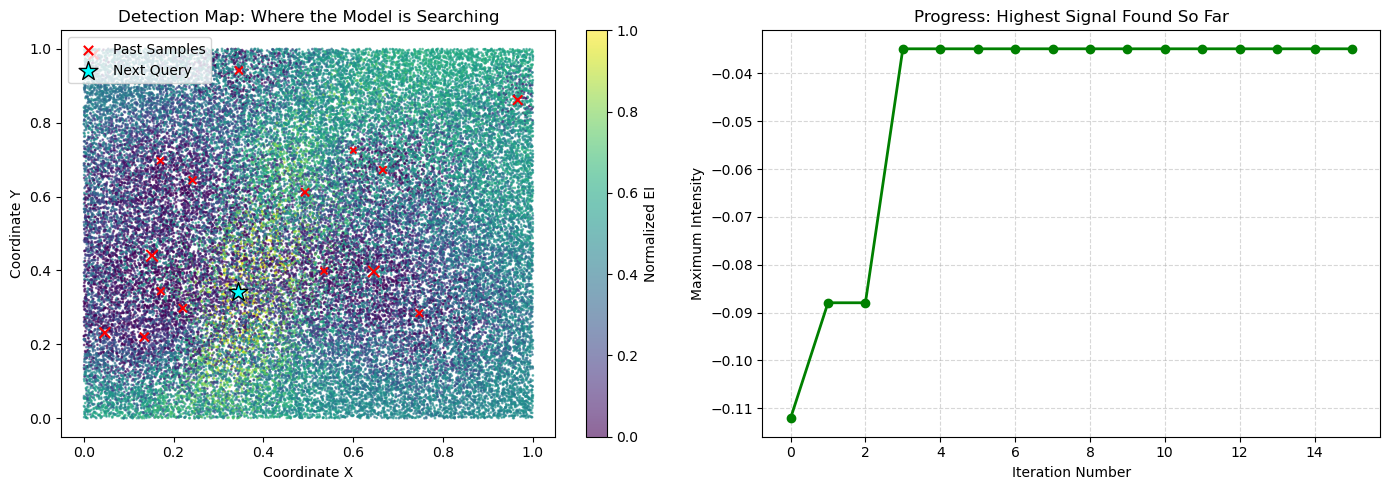

Strategic Result: Next point to query is at [0.342299-0.341527-0.471239]


In [10]:
# Calculate running maximum of observed values for progress plot
running_max = np.maximum.accumulate(Y_updated)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Define the acquisition function used for plotting.
acquisition_function = ei_values
acq_norm = (acquisition_function - np.nanmin(acquisition_function)) / (np.nanmax(acquisition_function) - np.nanmin(acquisition_function) + 1e-12)

# The Search Map (Where are we looking?)
# This shows the "hot zones" the model wants to explore next.
sc = ax1.scatter(x_grid[:, 0], x_grid[:, 1], c=acq_norm, cmap='viridis', s=1, alpha=0.6)
cbar = plt.colorbar(sc, ax=ax1, label='Normalized EI')

# Plot past samples in 2D (use the 3rd coordinate to scale marker sizes if desired)
past_sizes = 50 * (X_updated[:, 2] - np.min(X_updated[:, 2])) / (np.ptp(X_updated[:, 2]) + 1e-12) + 20
ax1.scatter(X_updated[:, 0], X_updated[:, 1], c='red', marker='x', s=past_sizes, label='Past Samples')

# Plot next query in 2D (x and y only)
ax1.scatter(next_query[0], next_query[1], c='cyan', marker='*', s=200, edgecolors='black', label='Next Query')

ax1.set_title('Detection Map: Where the Model is Searching')
ax1.set_xlabel('Coordinate X')
ax1.set_ylabel('Coordinate Y')
ax1.legend()

# The Progress Plot (Are we finding anything?)
# A simple line graph showing the best detection score over time.
ax2.plot(running_max, color='green', linewidth=2, marker='o')
ax2.set_title('Progress: Highest Signal Found So Far')
ax2.set_xlabel('Iteration Number')
ax2.set_ylabel('Maximum Intensity')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Strategic Result: Next point to query is at [{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}]")